#### Notebook to test How to clean dFAD data with the speeds. 
- remove zero speeds
- high speeds
    - 1% are above 1 m/s of all the data
- remove dFADs with few data points or lots bad datapoints
- from the removed points also have to remove the Lat, lon, distance, time collumn,

In [29]:
import pandas as pd 
import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
from functions.funcs import *

In [30]:
data = gpd.read_parquet(r"Data\Palmyra Data\SAT_MI_FAD_Missing_Times.parquet")
NWR = gpd.read_file(r"Data/Palmyra_Shapefiles",layer = 'PAL_KING_NWR_12nm')

In [31]:
data, delx_long, dely_long= add_distance_collumns(data)
data = remove_no_TimeStamp(data)
data = add_delta_time_collums(data)
data = Add_x_y_speed_collums_TimeStamp(data)


c:\FATE\Code\functions\funcs.py:225: RuntimeWarning: divide by zero encountered in divide
  heading = np.atan(delx_long/dely_long)
c:\FATE\Code\functions\funcs.py:225: RuntimeWarning: invalid value encountered in divide
  heading = np.atan(delx_long/dely_long)
c:\FATE\Code\functions\funcs.py:833: RuntimeWarning: invalid value encountered in divide
  xspeed = xdistance/data.at[i,"Delta_Timestamps"].astype("float64")*convert
c:\FATE\Code\functions\funcs.py:837: RuntimeWarning: divide by zero encountered in divide
  yspeed = ydistance/data.at[i,"Delta_Timestamps"].astype("float64")*convert
c:\FATE\Code\functions\funcs.py:837: RuntimeWarning: invalid value encountered in divide
  yspeed = ydistance/data.at[i,"Delta_Timestamps"].astype("float64")*convert
c:\FATE\Code\functions\funcs.py:841: RuntimeWarning: divide by zero encountered in divide
  xyspeed = xydistance/data.at[i,"Delta_Timestamps"].astype("float64")*convert
c:\FATE\Code\functions\funcs.py:841: RuntimeWarning: invalid value enco

In [32]:
line = data.at[2931, "geometry"]
print(max(line.xy[0]))
print(min(line.xy[0]))
print(max(line.xy[1]))
print(min(line.xy[1]))
times = pd.to_datetime(data.at[2931, "TimeStamp"])
print(times.max())
print(times.min())

-160.7578
-163.6672
7.7502
7.566
2025-06-16 14:07:00
2025-06-08 06:07:00


In [33]:
data.columns

Index(['index', 'BuoyName', 'MinOfDate', 'MaxOfDate', 'TimeStamp', 'geometry',
       'x_deg', 'y_deg', 'x_km', 'y_km', 'xy_km', 'Delta_Timestamps',
       'x_speed', 'y_speed', 'xy_speed'],
      dtype='object')

#### Checking how many Bad points there are

In [34]:
def Column_to_List(data, column:str):
    long_list = []
    for i in range(len(data)):
        row = data.at[i, column]
        long_list.extend(row)
    return long_list


In [35]:
speed = np.array(Column_to_List(data,"xy_speed"))


In [36]:
speed_fast = speed[speed>2]
print(f"high speed: {len(speed_fast)/len(speed)*100}")

high speed: 0.06927927490634059


In [37]:
## slow speeds 
speed_slow = speed[speed<0.0001]
print(f"Slow Speeds: {len(speed_slow)/len(speed)*100:.3}%")

Slow Speeds: 3.24%


In [38]:
## This is the Filterning Method
speedt = data.at[1,"xy_speed"]

speedt_high = speedt>0.4
speedt_low = speedt<0.1

masked = speedt_high | speedt_low
masked =~ masked
speedt_filtered = speedt[masked]
print(len(speedt_high), len(speedt_low), len(speedt_filtered))

21 21 0


#### Removing the Bad points 

In [39]:
def Remove_speeds_high_low(data:gpd.GeoDataFrame):
    bad_points = []
    speeds = []
    Masks = [ ]
    for i in range(len(data)):
        speed = data.at[i, "xy_speed"]
        speed_high = speed>2
        speed_low = speed < 0.001
        masked = speed_high | speed_low
        masked =~ masked
        filtered_speed = speed[masked]
        bad_point = len(speed) - len(filtered_speed)
        
        speeds.append(filtered_speed)
        bad_points.append(bad_point)
        Masks.append(masked)
    
    dataclean = data.copy()
    #dataclean["xy_speed"] = speeds
    dataclean["points_removed"] = bad_points
    dataclean["Masked_array"] = Masks
    return dataclean 

In [40]:
def Remove_zero_timedeltas(data:gpd.GeoDataFrame):
    bad_points = []
    timedeltas = []
    masks = []
    for i in range(len(data)):
        dtimes = data.at[i,"Delta_Timestamps"]
        mask = np.array(dtimes) != np.timedelta64(0, "ns")
        filtered_delta = np.array(dtimes)[mask]
        bad_point = len(dtimes) - len(filtered_delta)
        timedeltas.append(filtered_delta)
        bad_points.append(bad_point)
        masks.append(mask)
    #data["Delta_Timestamps"] = timedeltas
    data["points_removed2"] = bad_points
    data["Masked_array2"] = masks

    return data


In [41]:
def Combine_masks(data):
    """
    Combine Masked_array from speed filter and Delta_Timestamps filter.
    Assumes both are boolean arrays of the same length per row.
    """
    combined_masks = []
    
    for i in range(len(data)):
        mask_speed = np.array(data.at[i, "Masked_array"])
        mask_delta = np.array(data.at[i, "Masked_array2"])
        
        # combine: keep points that pass both
        combined = mask_speed & mask_delta
        
        combined_masks.append(combined)
    
    dataclean = data.copy()
    dataclean["Masked_array_combined"] = combined_masks
    
    return dataclean

In [42]:
def Filter_geometry_obj(row):
    coords = np.asarray(row.geometry.coords)
    coords = coords[1:]
    filtered_coords = coords[row['Masked_array_combined']]
    if len(filtered_coords) > 1:
        return sp.geometry.LineString(filtered_coords)
    else:
    # Return an empty geometry if not enough points remain
        return None

    

In [43]:

def Filter_Rows(row,column):
    """Function implented to apply mask from bad point removal to to other columns
    if column size doesnt line up we remove the later point [1:]"""
    array =np.asarray(row[f"{column}"])
    if len(array) != len(row["Masked_array_combined"]):
        array = array[1:]
    filtered_data = array[row["Masked_array_combined"]]
    if len(filtered_data)>1:
        return filtered_data
    else:
        return None

In [44]:
#data = gpd.read_file(r"Data\Palmyra Data\MI_and_SAT_FAD_positions")

dataclean = Remove_speeds_high_low(data)
print(dataclean["points_removed"].sum())
dataclean = Remove_zero_timedeltas(dataclean)
print(dataclean["points_removed2"].sum())
dataclean = Combine_masks(dataclean)
dataclean = dataclean.reset_index(drop = True)

8712
46745


In [45]:
### Removing The bad points in Geometry 
dataclean["new_geometry"] = dataclean.apply(Filter_geometry_obj, axis = 1)
dataclean["geometry"] = dataclean["new_geometry"]
dataclean = dataclean.drop(columns = ["new_geometry"])
valid_mask = ~dataclean.geometry.isna() & ~dataclean.geometry.is_empty
dataclean = dataclean[valid_mask]

In [46]:
### Removing 

columnlist = ['x_deg', 'y_deg', 'x_km', 'y_km', 'xy_km', 'TimeStamp', "x_speed","y_speed", "xy_speed","Delta_Timestamps" ]

for names in columnlist: 
    print(names)
    dataclean[f"new_{names}"] = dataclean.apply(Filter_Rows, axis =1, column = names)
    dataclean[f"{names}"] = dataclean[f"new_{names}"] 
    dataclean = dataclean.drop(columns = [f"new_{names}"])

dataclean = dataclean.reset_index(drop = True)

x_deg
y_deg
x_km
y_km
xy_km
TimeStamp
x_speed
y_speed
xy_speed
Delta_Timestamps


In [47]:
##Checking to see if it is cleaned
Delta_Timestamps = Column_to_List(dataclean,"Delta_Timestamps")
below1s = np.sum(Delta_Timestamps <= np.timedelta64(0, "ns"))
print(below1s)
print(Delta_Timestamps[:20])
speeds  = np.array(Column_to_List(dataclean,"xy_speed"))
print(np.sum(np.isnan(speeds)))

0
[np.timedelta64(10860,'ns'), np.timedelta64(12300,'ns'), np.timedelta64(9240,'ns'), np.timedelta64(10800,'ns'), np.timedelta64(10800,'ns'), np.timedelta64(10800,'ns'), np.timedelta64(10800,'ns'), np.timedelta64(11880,'ns'), np.timedelta64(9720,'ns'), np.timedelta64(10800,'ns'), np.timedelta64(10800,'ns'), np.timedelta64(10800,'ns'), np.timedelta64(10800,'ns'), np.timedelta64(10800,'ns'), np.timedelta64(10800,'ns'), np.timedelta64(11820,'ns'), np.timedelta64(9780,'ns'), np.timedelta64(10800,'ns'), np.timedelta64(10800,'ns'), np.timedelta64(10800,'ns')]
0


In [48]:
dataclean.to_parquet(r"Data\Palmyra Data\SAT_MI_FAD_cleanedspeeds.parquet")

In [49]:
data["MaxOfDate"] = pd.to_datetime(data["MaxOfDate"])
data["MaxOfDate"].min()

Timestamp('2021-06-29 05:12:00')

In [50]:
dataclean.columns

Index(['index', 'BuoyName', 'MinOfDate', 'MaxOfDate', 'TimeStamp', 'geometry',
       'x_deg', 'y_deg', 'x_km', 'y_km', 'xy_km', 'Delta_Timestamps',
       'x_speed', 'y_speed', 'xy_speed', 'points_removed', 'Masked_array',
       'points_removed2', 'Masked_array2', 'Masked_array_combined'],
      dtype='object')

In [51]:
ds = gpd.read_parquet(r"Data\Palmyra Data\SAT_MI_FAD_cleanedspeeds.parquet")
speeds = Column_to_List(ds,"xy_speed")
print(max(speeds))

1.9960106830662765


#### Plotting the Diffence between the trajectories

9


AttributeError: 'Figure' object has no attribute 'closefig'

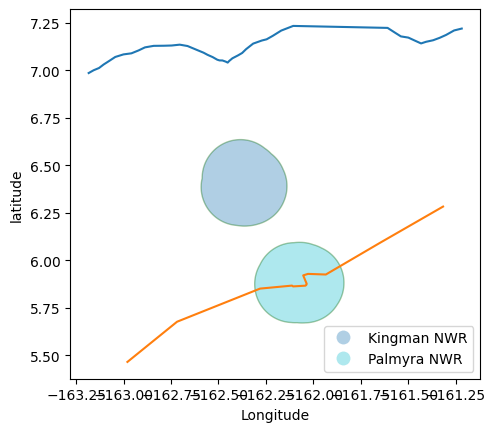

In [52]:
dataplotting = dataclean.query("points_removed > 5 ")
buoys = dataplotting["BuoyName"].unique()
for bouy in buoys:
    fig, ax = plt.subplots()
    n = dataplotting.loc[dataplotting["BuoyName"] == bouy].index.astype(int)
    print(n[0])
    OneTrajectory(ax,data,n[0])
    OneTrajectory(ax,dataclean,n[0])
    plot_NWPs(ax,NWR)
    fig.savefig(fr"..\Figures\Cleaning Data\CleanvsrawdFAD_{n[0]}.png")
    fig.closefig()

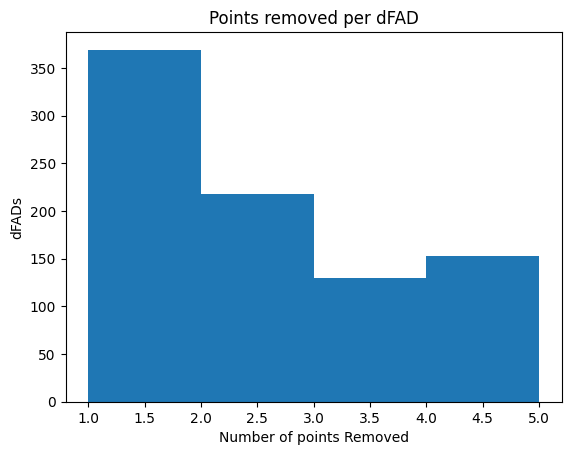

In [ ]:
fig, ax = plt.subplots()
ax.hist(dataclean["points_removed"], bins= [1,2,3,4,5])
ax.set_title("Points removed per dFAD")
ax.set_xlabel("Number of points Removed")
ax.set_ylabel("dFADs")
fig.savefig("Number of Points Removed.png")